Lab 1 Part B: OOP Informed Search Algorithms for Drone Pathfinding

1. Setup and Imports

In [28]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

2. Foundations from Part A

In [29]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""

In [30]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [31]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []
        row, col = state
        for actions in MOVES:
            dr, dc = MOVES[actions]
            neig_cell = (row + dr, col + dc)
            if self.in_bounds(neig_cell) and self.is_free(neig_cell):
                legal_actions.append(actions)
        return legal_actions
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        dr, dc = MOVES[action]
        next_state = (row + dr, col + dc)
        return next_state
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")


class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [32]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

3. Weighted Terrain: WeightedGridProblem

In [33]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        row, col = next_state
        return self.terrain_costs[row][col]
        raise NotImplementedError("Complete WeightedGridProblem.action_cost")

3.1 Self-Check for WeightedGridProblem

In [34]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


4. Heuristic Functions

In [35]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)
    raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    r1, c1 = state
    r2, c2 = goal
    return math.dist(state, goal)
    raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

4.2 Self-Check for the Heuristics

In [36]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


5. The Priority-Queue Frontier

In [37]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

6. The BestFirstSearch Framework

In [38]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        # 5. While the frontier is not empty:
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.

        node = Node(problem.initial_state())
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)

        reached = {node.state: node}

        nodes_expanded = 0
        max_frontier_size = 1

        while len(frontier) > 0:
            node = frontier.pop()
            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state

                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child

                    frontier.push(
                        self.evaluation(child, problem),
                        child,
                    )
            max_frontier_size = max(
                max_frontier_size,
                len(frontier),
            )

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )
        raise NotImplementedError("Complete BestFirstSearch.search")

7. Greedy Best-First Search

In [39]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)
        raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

8. A* Search

In [40]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)
        raise NotImplementedError("Complete AStarSearch.evaluation")

9. Uniform-Cost Search as a Special Case (Provided)

In [41]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

10. Weighted A* Search

In [42]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node, problem)
        raise NotImplementedError("Complete WeightedAStarSearch.evaluation")

10.1 Self-Check for the Algorithms

In [43]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, (
        f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    )
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0], [1, 1, 0], [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


11. Run the Algorithms on the Part A Sample Map

In [44]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)
     

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


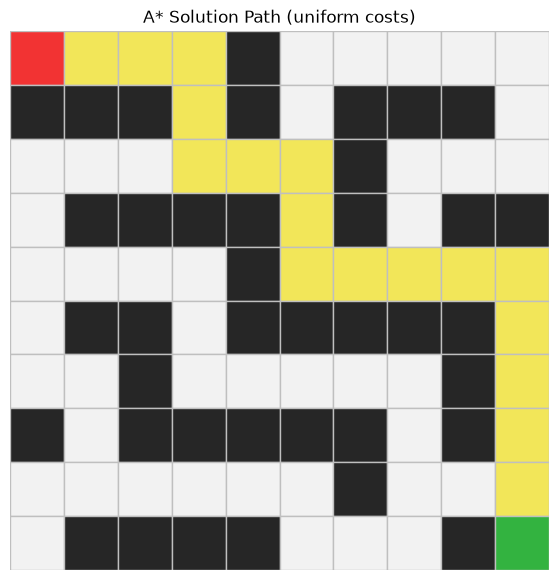

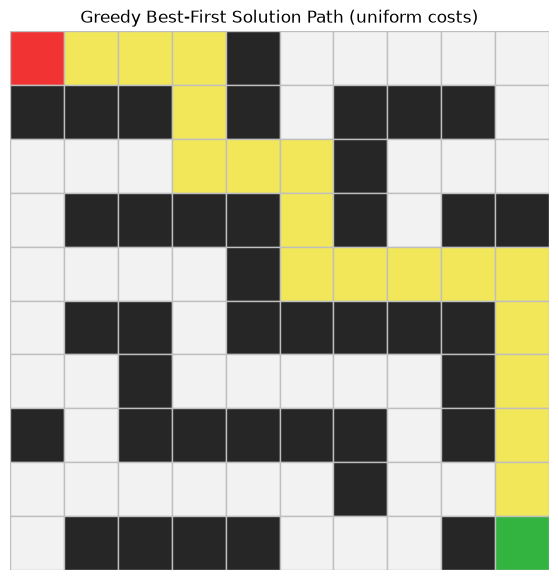

In [45]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

12. The Turbulence Map: Where Greedy Goes Wrong

In [46]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


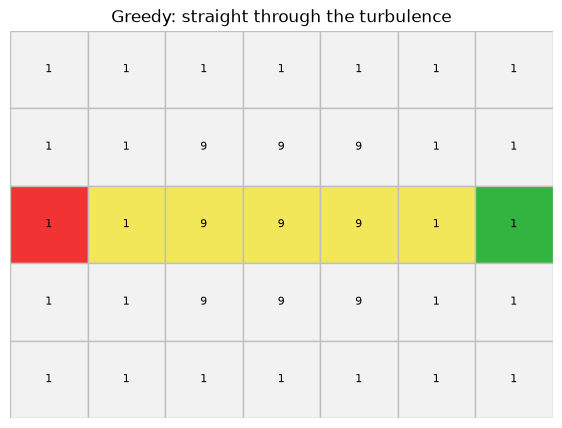

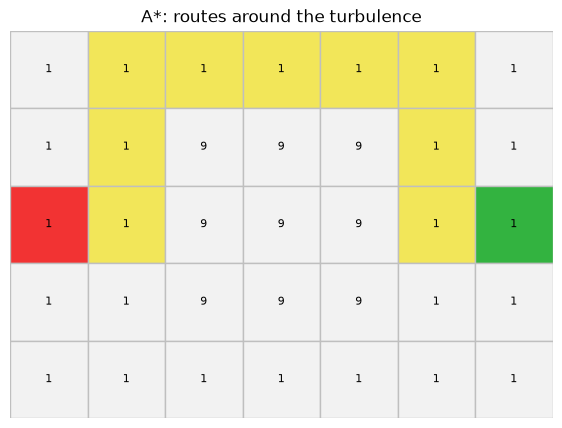

In [47]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

13. Experiment: Breaking Admissibility

In [48]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    

    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    return h
    raise NotImplementedError("Complete inflated_heuristic")


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


### Observations

- 1. On which map(s) did the inflated heuristic return a suboptimal path? By how much?

The inflated heuristic returned a suboptimal path on the mild turbulence map. The admissible A* found a path with a cost of 10, while the inflated heuristic found a path with a cost of 12. The difference was2 cost units. On the uniform map, both heuristics found the same solution cost of 18.

- 2. How many fewer nodes did it expand?

On the uniform map, both heuristics expanded 18 nodes, so there was no difference.
On the mild turbulence map, the admissible A* expanded 29 nodes, while the inflated heuristic expanded 6 nodes. Therefore, the inflated heuristic expanded 23 fewer nodes.

- 3. When would you deliberately accept an inadmissible heuristic?

I would accept an inadmissible heuristic when a fast solution is more important than the best solution. For example, in an emergency, the drone may need a good path quickly rather than the optimal path.


14. Bonus (Optional): Iterative-Deepening A* (IDA*)

In [49]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
       

        start = Node(problem.initial_state())

        limit = self.heuristic(start.state, problem.goal)

        nodes_expanded = 0
        max_frontier_size = 0
        iteration_log = []

        def on_path(node: Node, state) -> bool:
            current = node
            while current is not None:
                if current.state == state:
                    return True
                current = current.parent
            return False

        def f_limited_search(node: Node, limit: float):

            nonlocal nodes_expanded, max_frontier_size

            max_frontier_size = max(max_frontier_size, node.depth + 1)

            f = node.path_cost + self.heuristic(node.state, problem.goal)

            if f > limit:
                return None, f

            if problem.is_goal(node.state):
                return node, f

            nodes_expanded += 1

            next_limit = float("inf")

            for child in self.expand(problem, node):

                # path-cycle checking
                if on_path(node, child.state):
                    continue

                result, new_f = f_limited_search(child, limit)

                if result is not None:
                    return result, new_f

                next_limit = min(next_limit, new_f)

            return None, next_limit

        for iteration in range(max_iterations):

            result, next_limit = f_limited_search(start, limit)

            iteration_log.append(
                {
                    "limit": limit,
                    "outcome": "success" if result is not None else next_limit,
                }
            )

            if result is not None:
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=result,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iteration_log,
                )

            if next_limit == float("inf"):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="failure",
                    solution=None,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    iterations=iteration_log,
                )

            limit = next_limit

        return SearchResult(
            algorithm=self.algorithm_name,
            status="cutoff",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            iterations=iteration_log,
        )
        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

15. Create Your Own Maps

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,28,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,14,13,27
3,Greedy,success,6,27,6,13,19


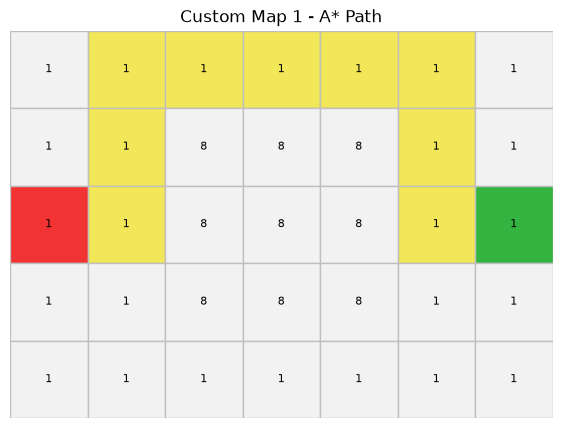

In [50]:
# TODO 10:
# Create your first custom map here.
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 8, 8, 8, 1, 1],
    [1, 1, 8, 8, 8, 1, 1],
    [1, 1, 8, 8, 8, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

custom_start_1 = (2, 0)
custom_goal_1 = (2, 6)

# Example after completing:
# custom_problem_1 = WeightedGridProblem(
#     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
# )
# custom_results_1 = [
#     ucs.search(custom_problem_1),
#     astar.search(custom_problem_1),
#     wastar2.search(custom_problem_1),
#     greedy.search(custom_problem_1),
# ]
# show_results(custom_results_1)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    terrain_costs=custom_costs_1,
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

display(show_results(custom_results_1))

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    terrain_costs=custom_costs_1,
    title="Custom Map 1 - A* Path",
)

Interpretation: In this map, the direct route passes through expensive terrain with a cost of 8. Greedy chose the direct path and ended with a much higher cost of 27. A*, UCS, and Weighted A* all found the cheaper path with a cost of 10. Weighted A* performed best because it found the optimal path while expanding only 14 nodes.

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,28,28,126,7,130
1,A*,success,28,28,83,8,90
2,Weighted A* (W=2),success,28,28,28,7,35
3,Greedy,success,28,28,28,7,35


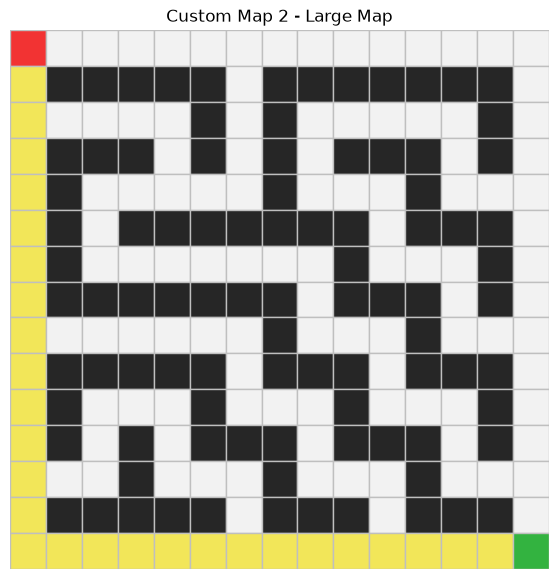

In [51]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
    [0,0,0,0,0,1,0,1,0,0,0,0,0,1,0],
    [0,1,1,1,0,1,0,1,0,1,1,1,0,1,0],
    [0,1,0,0,0,0,0,1,0,0,0,1,0,0,0],
    [0,1,0,1,1,1,1,1,1,1,0,1,1,1,0],
    [0,1,0,0,0,0,0,0,0,1,0,0,0,1,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,0,1,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,0,1,1,1,0],
    [0,1,0,0,0,1,0,0,0,1,0,0,0,1,0],
    [0,1,0,1,0,1,1,1,0,1,1,1,0,1,0],
    [0,0,0,1,0,0,0,1,0,0,0,1,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,0,1,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (14, 14)

# Example after completing:
# custom_problem_2 = WeightedGridProblem(
#     custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
# )
# custom_results_2 = [
#     ucs.search(custom_problem_2),
#     astar.search(custom_problem_2),
#     wastar2.search(custom_problem_2),
#     greedy.search(custom_problem_2),
# ]
# show_results(custom_results_2)
custom_problem_2 = GridProblem(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

display(show_results(custom_results_2))
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="Custom Map 2 - Large Map",
)

Interpretation: The map shows the benefit of using a heuristic. UCS expanded 126 nodes, while A* expanded only 83 and still found the same optimal path. Weighted A* and Greedy expanded only 28 nodes and found the same solution cost of 28. On this map, Weighted A* gave the best balance between solution quality and search effort.

16. Reflection Questions

1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?

h(n) estimates how far a node is from the goal. In this lab, it gets that information from the coordinates of the current cell and the goal.

2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

It removes obstacles and terrain costs. It assumes every move costs 1 and the drone can move freely to the goal.

3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

Manhattan distance dominates Euclidean distance because it gives a larger estimate without overestimating. It should expand fewer nodes.

4. Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

If every move costs at least 1, the real path cost cannot be less than the Manhattan distance. With a cost of 0.5, the actual cost could become smaller than the heuristic, so the heuristic would overestimate.ld become smaller than the Manhattan distance, making the heuristic overestimate and lose admissibility.

16.2 Greedy Best-First Search


1. Which quantity does Greedy ignore, and how did the turbulence map punish it for that?

Greedy ignores g(n). On the turbulence map, it went straight through the high-cost cells and got a cost of 30 instead of 10.

2. Greedy expanded fewer nodes than A on some maps. Why is that not enough to call it the better algorithm?*

Because expanding fewer nodes only means it searched faster. In the turbulence map, it was faster but found a much more expensive path.

3. Describe a drone mission where Greedy's behaviour would actually be acceptable.

A search-and-rescue mission where finding a path quickly is more important than finding the cheapest path.

16.3 A* Search


1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.

A* chooses the route with the lowest estimated total cost by combining the cost already travelled and the estimated cost left to the goal.

2. Why must A apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?*

Because a cheaper path may still be in the frontier. On the turbulence map, A* could accept the expensive route through the turbulence before finding the cheaper route around it.

3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?

Because the same state can be reached with different costs. The dictionary keeps the cheapest path to that state.

4. Compare the nodes expanded by UCS and A on the sample map. What does this gap tell you about the value of the heuristic?*

UCS expanded 52 nodes while A* expanded 18. This shows the heuristic helped A* reach the goal with much less search.

16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?

An admissible heuristic never overestimates the true cost to the goal. A consistent heuristic satisfies the triangle inequality. Consistency implies admissibility.

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

The admissible heuristic found the optimal cost of 10, while the inflated heuristic found a cost of 12. This showed that A* is not guaranteed to be optimal when the heuristic is inadmissible.

3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n,a,n') + h(n') for a single move and explain.

Yes. A single move changes the Manhattan distance by at most 1, and each move costs 1. So the triangle inequality is satisfied.

16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A, and Greedy?*

When W = 0, it behaves like UCS. When W = 1, it becomes A*. As W increases, it behaves more like Greedy by giving more importance to the heuristic.

2. What suboptimality bound does Weighted A guarantee, and did your experiments stay well inside that bound?*

Weighted A* guarantees a solution cost no more than W times the optimal cost. With W = 2, the optimal cost was 10 and Weighted A* also found a cost of 10, so it stayed well inside the bound.

3. The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

I would choose Weighted A* with W = 2 because it expanded fewer nodes than A* while still finding the optimal path in our experiments.

16.6 Memory and Real-World Drone Context

1. Which data structures make A memory-hungry? How does IDA (bonus) avoid this, and what does it pay instead?**

A* uses a frontier and a reached dictionary, which can become very large. IDA* uses much less memory but re-expands nodes many times.

2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out?

Weather conditions, wind speed, battery level, temporary no-fly zones, and obstacle density.

3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts become relevant?

The heuristic can become inaccurate because the goal keeps changing position. Real-time search and learned heuristics become more useful.

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

I would choose A* because it found the optimal path while expanding far fewer nodes than UCS. I would reconsider if memory or processing power became a major limitation, in which case I would use Weighted A* or IDA*.